this cell only needs to be run once to filter dataset, unless we decide to chagne hwo we filter it no need to run again

In [2]:
# import pandas as pd

# # Path to dataset
# filepath = "Datasets/chicago_full.csv"

# # Load dataset
# df = pd.read_csv(filepath, engine="python", on_bad_lines="skip")

# # Convert Date column to datetime
# df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p")

# # Filter rows between 2021 and 2026
# filtered_df = df[(df["Date"] >= "2021-03-07") & (df["Date"] <= "2026-03-7")]

# # Save result
# filtered_df.to_csv("Datasets/chicago_filtered.csv", index=False)

# print("Filtered dataset saved.")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

filepath = "weather_crime_final.csv"

df = pd.read_csv(filepath)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Keep only crime columns
crime_df = df[['date', 'city', 'total_crime_count', 'violent_count', 'property_count', 'other_count']]

# Set date index
crime_df = crime_df.set_index('date')

print(crime_df.head())
print(crime_df.describe())

                       city  total_crime_count  violent_count  property_count  \
date                                                                            
2022-01-01  Charlottesville                 15              0               2   
2022-01-02  Charlottesville                 11              0               2   
2022-01-03  Charlottesville                  8              0               1   
2022-01-04  Charlottesville                 16              0               1   
2022-01-05  Charlottesville                 12              0               0   

            other_count  
date                     
2022-01-01           13  
2022-01-02            9  
2022-01-03            7  
2022-01-04           15  
2022-01-05           12  
       total_crime_count  violent_count  property_count  other_count
count        5844.000000    5844.000000     5844.000000  5844.000000
mean          574.271389     143.966461      274.433949   155.870979
std           609.324107     151.033746    

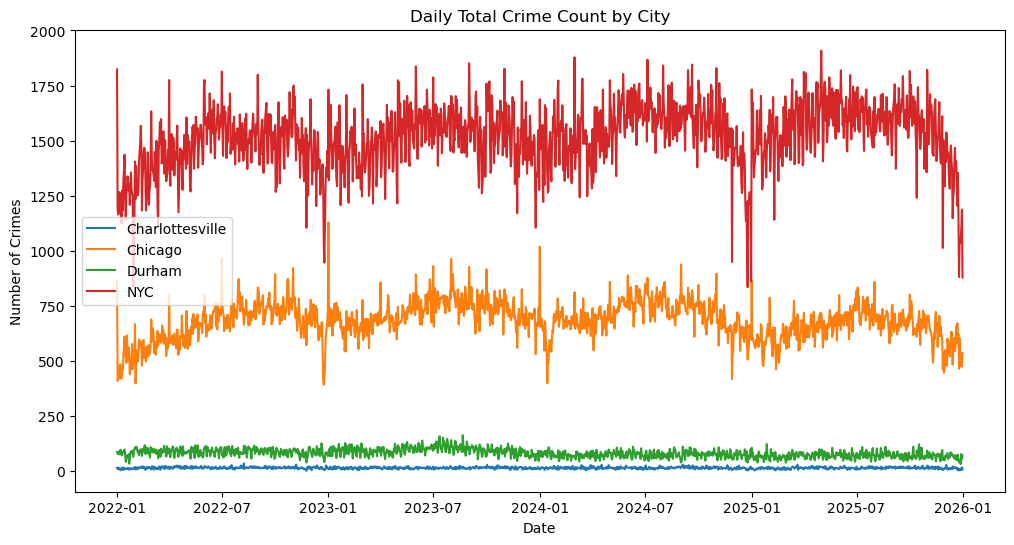

In [4]:
crime_by_city = crime_df.pivot_table(
    index='date',
    columns='city',
    values='total_crime_count'
)

plt.figure(figsize=(12,6))

for city in crime_by_city.columns:
    plt.plot(crime_by_city.index, crime_by_city[city], label=city)

plt.title("Daily Total Crime Count by City")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")

plt.legend()
plt.savefig("Outputs/crime_by_city.png", bbox_inches="tight")
plt.show()

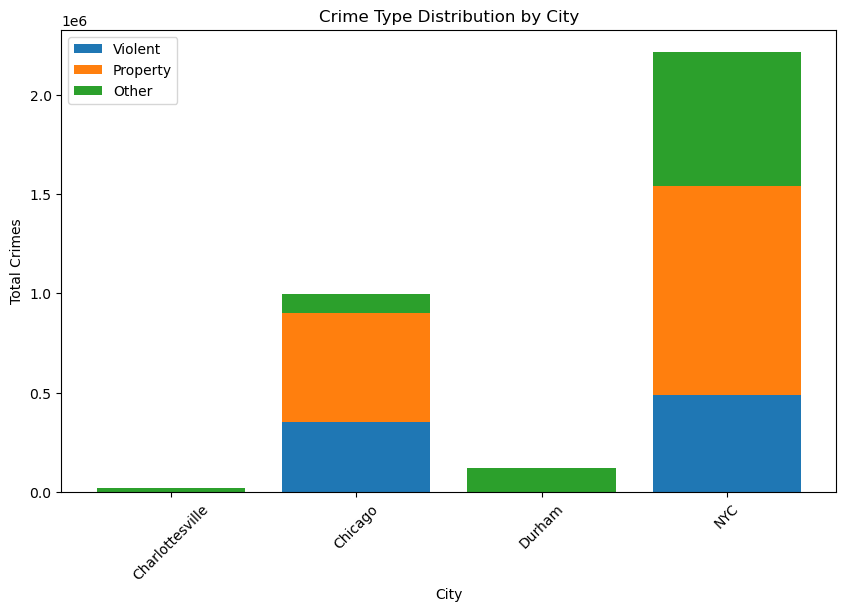

In [5]:
crime_types_city = crime_df.groupby('city')[[
    'violent_count',
    'property_count',
    'other_count'
]].sum()

plt.figure(figsize=(10,6))

plt.bar(crime_types_city.index, crime_types_city['violent_count'], label='Violent')
plt.bar(crime_types_city.index, crime_types_city['property_count'],
        bottom=crime_types_city['violent_count'], label='Property')

bottom_stack = crime_types_city['violent_count'] + crime_types_city['property_count']

plt.bar(crime_types_city.index, crime_types_city['other_count'],
        bottom=bottom_stack, label='Other')

plt.title("Crime Type Distribution by City")
plt.xlabel("City")
plt.ylabel("Total Crimes")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("Outputs/crime_types_by_city.png", bbox_inches="tight")
plt.show()

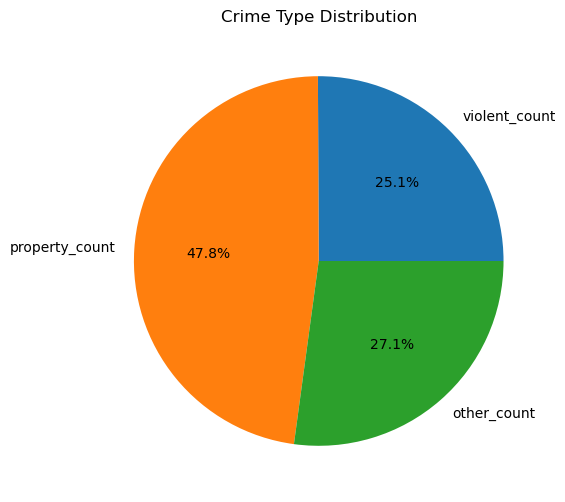

In [6]:
crime_totals = crime_df[['violent_count','property_count','other_count']].sum()

plt.figure(figsize=(6,6))
plt.pie(crime_totals,
        labels=crime_totals.index,
        autopct='%1.1f%%')

plt.title("Crime Type Distribution")

plt.savefig("Outputs/crime_distribution.png", bbox_inches="tight")
plt.show()

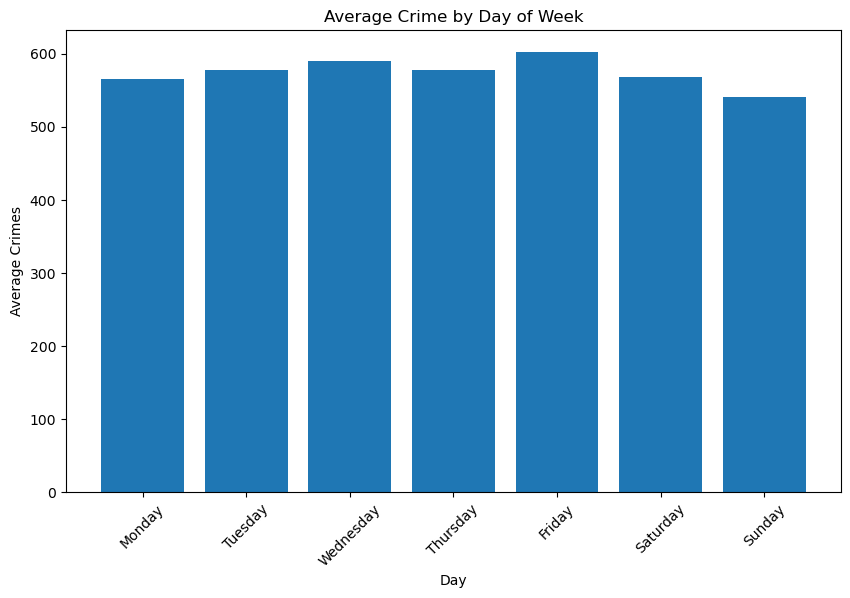

In [7]:
crime_df['day_of_week'] = crime_df.index.day_name()

crime_by_day = crime_df.groupby('day_of_week')['total_crime_count'].mean()

order = [
    'Monday','Tuesday','Wednesday','Thursday',
    'Friday','Saturday','Sunday'
]

crime_by_day = crime_by_day.reindex(order)

plt.figure(figsize=(10,6))
plt.bar(crime_by_day.index, crime_by_day.values)

plt.title("Average Crime by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Crimes")

plt.xticks(rotation=45)

plt.savefig("Outputs/crime_by_day.png", bbox_inches="tight")
plt.show()